In [1]:
import pickle
import pandas as pd
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pickle
import os
import scanpy as sc
import numpy as np
import scperturb
import re, math
import gseapy as gp
import matplotlib.ticker as mticker

/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/anndata

In [2]:
import warnings
from hypermap import HyperMAP
import json
from hypermap.evaluate import (
    plot_metric_boxgrid,
    plot_context_boxplot,
    top_genes_global,
    plot_top20_corr_for_gene,
)
warnings.filterwarnings('ignore')

Load iPSC processed data

In [3]:
adata=sc.read_h5ad('data/ipsc_hvg_2500_norm.h5ad')
adata.X=adata.X.toarray()
adata=adata[adata.obs['condition'].isin(genes)]
adata.obs['context_cell']=adata.obs['Cell_Line'].str.split('_',expand=True)[0]
pert_test = adata.obs['condition'][adata.obs['condition']!='ctrl'].unique()

### Fig 2d,h,i

In [4]:
gene_embeddings = pd.read_pickle('data/GPT_3_5_gene_embeddings_3-large.pickle')
genes=list(gene_embeddings.keys())
genes.append('ctrl')

iPSC HyperMap LOO testing

In [14]:
model = HyperMAP(
    adata        = adata,
    gene_emb     = gene_embeddings,
    project_name = "ipsc_run1",   # change this name for a fresh cache
    inner_lr = 0.005,
    n_adapt_steps = 1,
    batch_size=512,
    n_adapt_genes = 10,
    training_epochs=50,
    seed=1234
)

[HyperMAP] Using device: cuda


/tmp/ipykernel_1890359/3588247813.py:1: UserWarning: Cache directory 'hypermap_cache/ipsc_run1' already exists.
Existing cached context data will be reused.
If your data has changed, use a different project_name for a fresh run.
  model = HyperMAP(


[HyperMAP] Computing context-specific control means...
[HyperMAP] Computing delta (normalized expression)...
[HyperMAP] Assigning perturbation embeddings...



%|          | 0/437 [00:00<?, ?it/s]
%|▏         | 8/437 [00:00<00:05, 72.26it/s]
%|▍         | 17/437 [00:00<00:05, 80.92it/s]
%|▋         | 29/437 [00:00<00:04, 97.33it/s]
%|▉         | 39/437 [00:00<00:04, 97.39it/s]
%|█▏        | 51/437 [00:00<00:03, 103.57it/s]
%|█▍        | 63/437 [00:00<00:03, 108.77it/s]
%|█▋        | 74/437 [00:00<00:03, 103.87it/s]
%|█▉        | 86/437 [00:00<00:03, 108.64it/s]
%|██▏       | 97/437 [00:00<00:03, 105.89it/s]
%|██▍       | 108/437 [00:01<00:03, 104.33it/s]
%|██▋       | 120/437 [00:01<00:02, 106.03it/s]
%|███       | 132/437 [00:01<00:02, 107.69it/s]
%|███▎      | 144/437 [00:01<00:02, 108.83it/s]
%|███▌      | 157/437 [00:01<00:02, 112.49it/s]
%|███▊      | 169/437 [00:01<00:02, 109.50it/s]
%|████▏     | 181/437 [00:01<00:02, 111.18it/s]
%|████▍     | 193/437 [00:01<00:02, 112.10it/s]
%|████▋     | 206/437 [00:01<00:02, 115.04it/s]
%|█████     | 219/437 [00:02<00:01, 118.91it/s]
%|█████▎    | 232/437 [00:02<00:01, 121.51it/s]
%|█████▌    | 24

[HyperMAP] Initialised. Contexts: 10  |  Conditions: 437  |  Embedding dim: 3072  |  Genes: 2500


In [15]:
loo_results = model.loo()


[LOO] Test context: eipl
  [cache] Loading fiaj...
  [cache] Loading iudw...
  [cache] Loading jejf...
  [cache] Loading kolf...
  [cache] Loading oikd...
  [cache] Loading paab...
  [cache] Loading pipw...
  [cache] Loading tolg...
  [cache] Loading zapk...



ining:   2%|▏         | 1/50 [00:01<01:27,  1.79s/it]

  Epoch 1/50  meta-loss: 57.5645



ining:   4%|▍         | 2/50 [00:03<01:24,  1.76s/it]

  Epoch 2/50  meta-loss: 60.8656


...


Training: 100%|██████████| 50/50 [01:33<00:00,  1.86s/it]

  Epoch 50/50  meta-loss: 56.2985
  Gene coverage: 436/436 (100.0%)
  [save] Model saved → hypermap_cache/ipsc_run1/model_loo_zapk.pt

[LOO] Evaluating zapk...


  [adapt] zapk  strategy=random  n_adapt_genes=10...
    initial adapt loss: 54.8220
    final adapt loss:   50.7821


/cellar/users/bdhaka/miniforge3/envs/gear/lib/python3.11/site-packages/torch/nn/modules/module.py:811: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1737622248491/work/build/aten/src/ATen/core/TensorBody.h:489.)
  param_grad = param.grad


  Perts predicted: 436  |  with ground truth: 436  |  NA: 0

[HyperMAP] Run complete.
  Meta-training : 50/50 epochs clean.
  Adaptation    : all 10 context(s) completed successfully.



In [17]:
with open('model_results/ipsc_hypermap.pkl', 'wb') as f:
    pickle.dump(loo_results, f)
print("Saved: model_results/ipsc_hypermap.pkl")

Saved: model_results/ipsc_hypermap.pkl


Load results

In [36]:
with open('data/scpram_ipsc.pkl', 'rb') as file:
        scpram = pickle.load(file)
with open('data/gears_ipsc.pkl', 'rb') as file:
        gears = pickle.load(file)
with open('data/scgpt_ipsc.pkl', 'rb') as file:
        scgpt = pickle.load(file)
with open('data/top_20_ipsc.pkl', 'rb') as file:
        top = pickle.load(file)

/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

[HyperMAP] Figure saved → t1.svg

── Median summary ──────────────────────────────────────────────
          Median Top-20 Pearson  Median Top-20 Recall  Median Top-20 MSE  p (Top-20 Pearson vs HyperMap)  p (Top-20 Recall vs HyperMap)  p (Top-20 MSE vs HyperMap)
Model                                                                                                                                                              
HyperMap                 0.8922                0.5050             0.0066                             NaN                            NaN                         NaN
scPRAM                   0.1425                0.0900             0.0647                             0.0                            0.0                         0.0
GEARS                    0.6002                0.3625             0.0219                             0.0                            0.0                         0.0
scGPT                    0.1242                0.0500             0.1170         

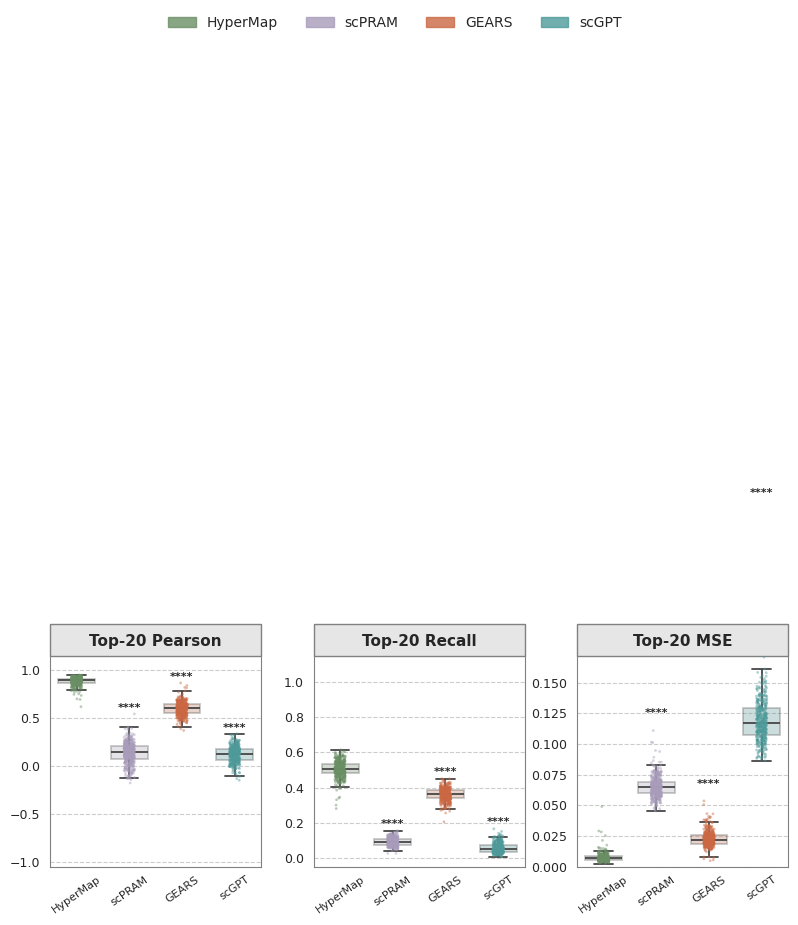

In [45]:
fig, df = plot_metric_boxgrid(
    objs_dict      = {'HyperMap': hypermap_dict, 'GEARS': gears_dict, 'scGPT': scgpt_dict, 'scPRAM': scpram_dict},
    colors_dict    = {'HyperMap': '#6a8f65', 'GEARS': '#cb6843', 'scPRAM': '#a89cba', 'scGPT': '#4e9a9a'},
    models         = ['HyperMap', 'scPRAM', 'GEARS', 'scGPT'],
    base_model     = 'HyperMap',
    figsize        = (8.5, 9),
    top_genes_dict = top_20
)

/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

[HyperMAP] Figure saved → t1.svg

── Median summary ──────────────────────────────────────────────
          Median Top-20 Pearson  Median Top-20 Recall  Median Top-20 MSE  p (Top-20 Pearson vs HyperMap)  p (Top-20 Recall vs HyperMap)  p (Top-20 MSE vs HyperMap)
Model                                                                                                                                                              
HyperMap                 0.8922                0.5050             0.0066                             NaN                            NaN                         NaN
scPRAM                   0.1425                0.0900             0.0647                             0.0                            0.0                         0.0
GEARS                    0.6002                0.3625             0.0219                             0.0                            0.0                         0.0
scGPT                    0.1242                0.0500             0.1170         

/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:578: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:584: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:578: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/cellar/users/bdhaka/projects/P2P/stable_run/hypermap_pkg/hypermap/evaluate.py:584: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

[HyperMAP] Figure saved → t2.svg


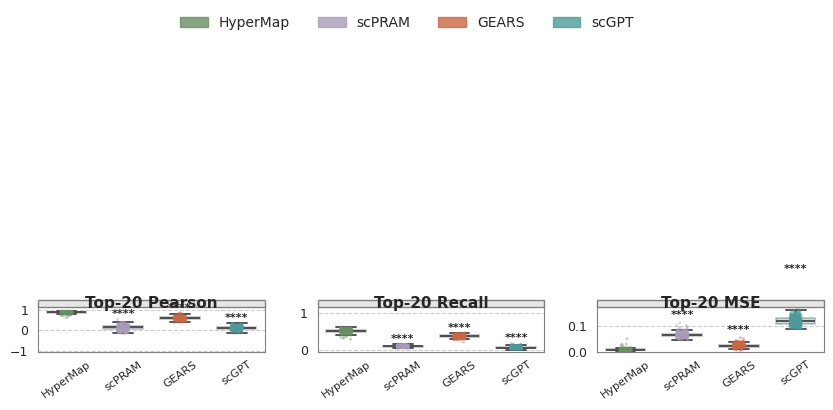

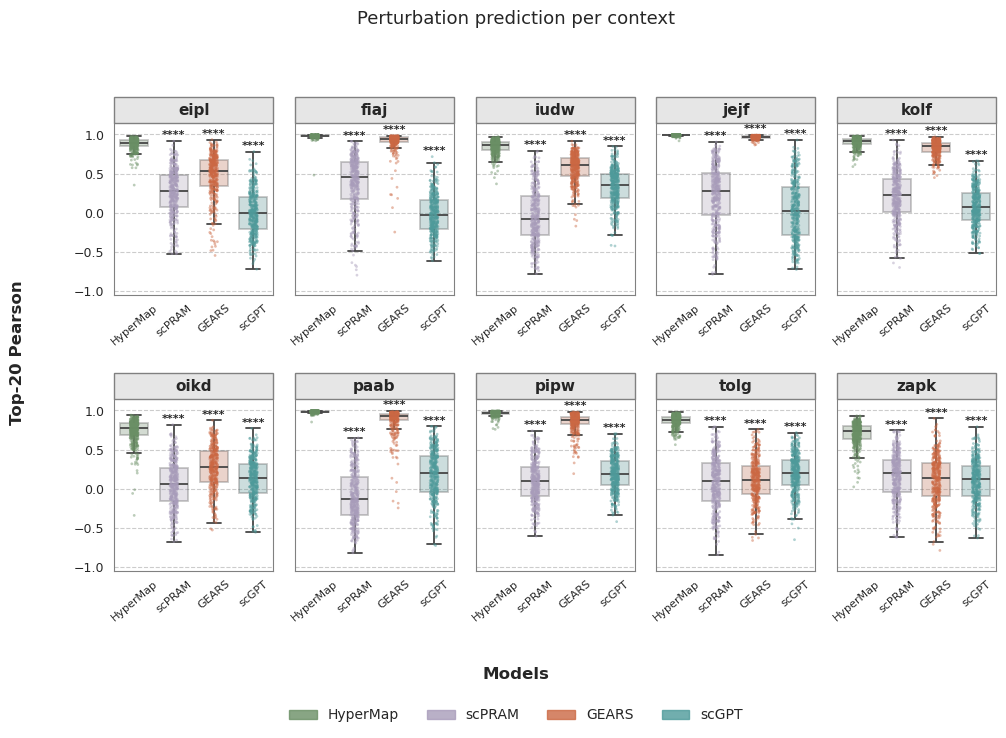

In [40]:
fig, df = plot_context_boxplot(
    objs_dict      = {'HyperMap': hypermap_dict, 'GEARS': gears_dict, 'scGPT': scgpt_dict, 'scPRAM': scpram_dict},
    colors_dict    = {'HyperMap': '#6a8f65', 'GEARS': '#cb6843', 'scPRAM': '#a89cba', 'scGPT': '#4e9a9a'},
    models         = ['HyperMap', 'scPRAM', 'GEARS', 'scGPT'],
    base_model     = 'HyperMap',
    top_k          = True,
    figsize        = (11, 7),
    top_genes_dict = top_20,
)

### Fig 2 f,g

[HyperMAP] Figure saved → Figures/Fig2f_g.svg


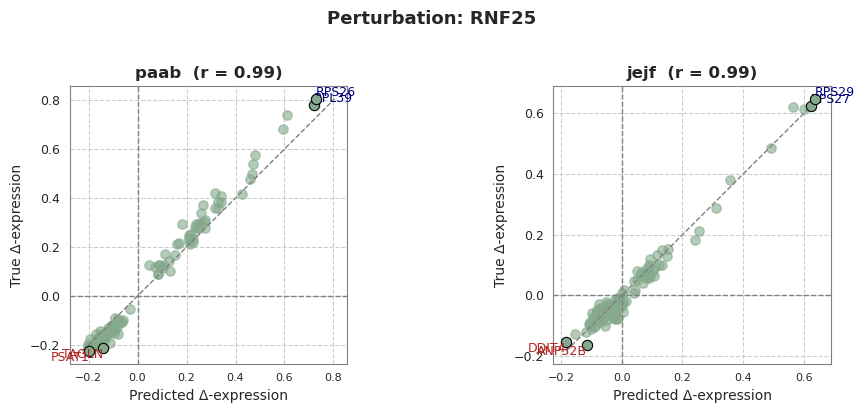

In [41]:
# 3. Top genes for a perturbation
top_genes = top_genes_global(adata, pert='RNF25',
                             contexts=['paab', 'jejf'],k=100)

# 4. Scatter per context for a specific pert
fig = plot_top20_corr_for_gene(
    loaded_object = loo_results,
    top_genes  = top_genes,
    gene          = 'RNF25',
    gene_list     = list(adata.var_names),
    donors        = ['paab', 'jejf'],
)